In [2]:
print("lets learn using dbscan")

lets learn using dbscan


[docs](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

In [3]:
from sklearn.cluster import DBSCAN

In [4]:
import multiprocessing
multiprocessing.cpu_count()

2

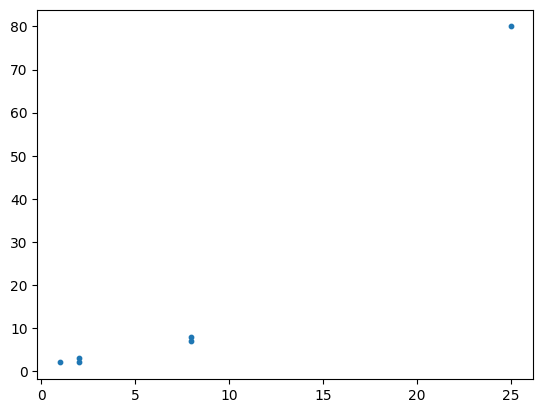

In [6]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[1, 2], [2, 2], [2, 3],
              [8, 7], [8, 8], [25, 80]])

plt.scatter(X[:,0], X[:,1],s=10)

DBSCAN can’t handle variable-density clusters in one run, you have to compromise or pick parameters that fit one region best.

In [7]:
clustering = DBSCAN(eps=3, min_samples=2).fit(X)

In [8]:
type(clustering)

sklearn.cluster._dbscan.DBSCAN

In [17]:
print(f"components: {clustering.components_}")
print(f"core sample indices: {clustering.core_sample_indices_}")
print(f"labels: {clustering.labels_}")
print(f"algorithm: {clustering.algorithm}") # instead of the default kdtree or balltree might be used for finding closest neighbours
print(f"leaf size: {clustering.leaf_size}") # mostly it will use kdtree or balltree
print(f"metric: {clustering.metric}") # mostly it will use euclidean distance
print(f"jobs: {clustering.n_jobs}")
print(f"jobs: {clustering.n_jobs}")
print(f"metric_params: {clustering.metric_params}")


components: [[1 2]
 [2 2]
 [2 3]
 [8 7]
 [8 8]]
core sample indices: [0 1 2 3 4]
labels: [ 0  0  0  1  1 -1]
algorithm: auto
leaf size: 30
metric: euclidean
jobs: None
jobs: None
metric_params: None


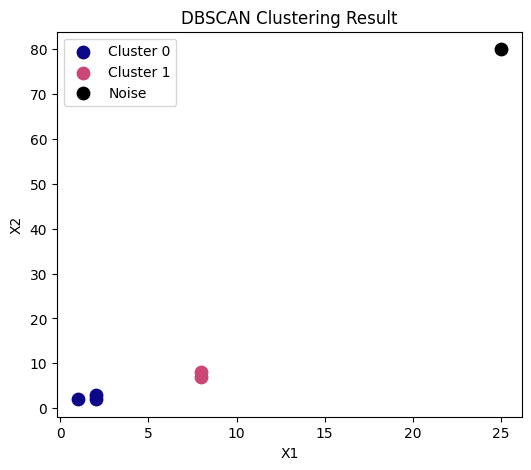

In [18]:
labels = clustering.labels_
plt.figure(figsize=(6, 5))
unique_labels = set(labels)
colors = plt.cm.plasma(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=80, c=[col], label=f"Cluster {k}" if k != -1 else "Noise")

plt.title("DBSCAN Clustering Result")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

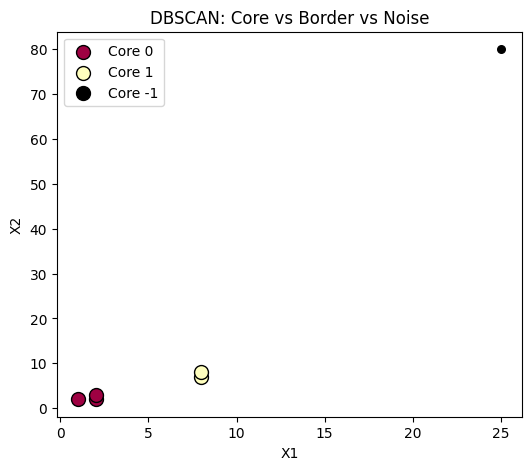

In [19]:
core_samples_mask = np.zeros_like(clustering.labels_, dtype=bool)
core_samples_mask[clustering.core_sample_indices_] = True

unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(6, 5))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # black for noise

    class_member_mask = (labels == k)

    # Core points (big)
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=100, c=[col], edgecolor='k', label=f'Core {k}')

    # Border points (small)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=30, c=[col], edgecolor='k')

plt.title("DBSCAN: Core vs Border vs Noise")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


In [20]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler


In [21]:
iris = datasets.load_iris()
X = iris.data
y = iris.target  # for comparison only

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [33]:
db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X_scaled)

In [34]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Estimated clusters: 2
Noise points: 26


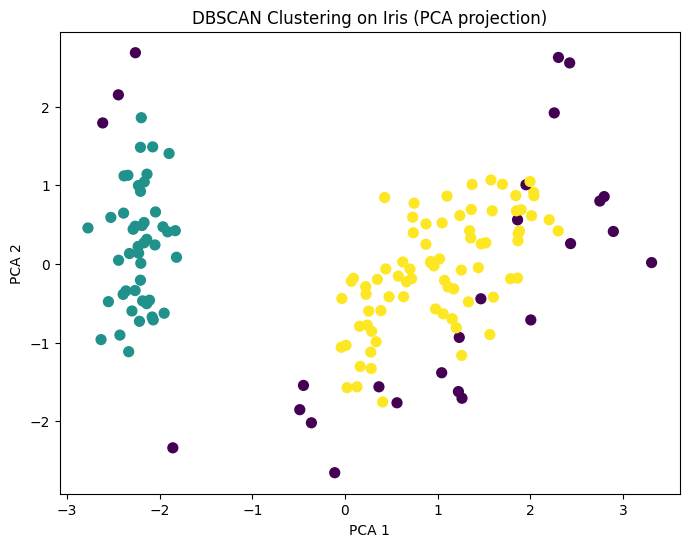

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering on Iris (PCA projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

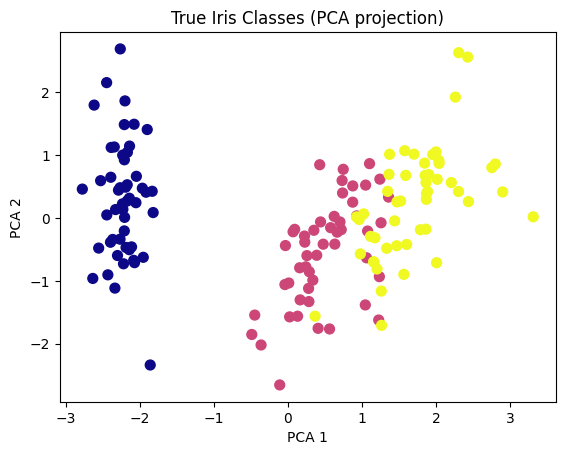

In [26]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='plasma', s=50)
plt.title("True Iris Classes (PCA projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

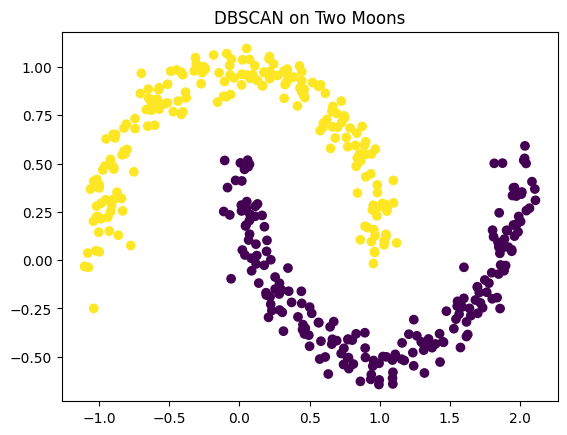

In [38]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=400, noise=0.07, random_state=42)

db = DBSCAN(eps=0.3, min_samples=5).fit(X) # with 0.4 it does a very bad job, all come under
labels = db.labels_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("DBSCAN on Two Moons")
plt.show()

So critical edges seem to be a problem? one in between point between your clusters can cause clusters to merge

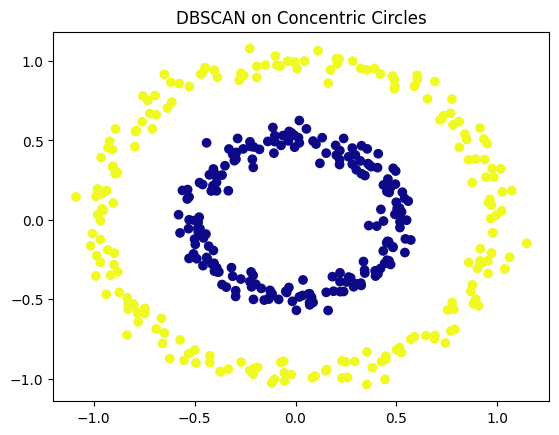

In [39]:
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)

db = DBSCAN(eps=0.15, min_samples=5).fit(X)
plt.scatter(X[:, 0], X[:, 1], c=db.labels_, cmap='plasma')
plt.title("DBSCAN on Concentric Circles")
plt.show()

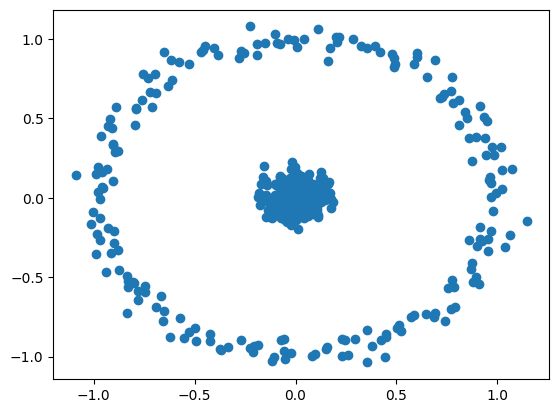

In [42]:
X, _ = make_circles(n_samples=400, factor=0.1, noise=0.05, random_state=42)
plt.scatter(X[:, 0], X[:, 1])